<a target="_blank" href="https://colab.research.google.com/github/upadhyan/SUDS-2026-Bootcamp-Friday/blob/main/labs/Supervised_Lab.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UofT DSI SUDS
#### Supervised Learning Lab
#### Teaching team: Nakul Upadhya
##### Lab author: Kyle E. C. Booth, kbooth@mie.utoronto.ca, edited by Jake Mosseri, Nakul Upadhya, Eldan Cohen, Alex Olson, Shehnaz Islam

In this lab, we will be introducing *decision tree and forests*. We will introduce the notion of a decision tree, extend this to random forests, and then investigate some state-of-the-art tree-based methods for machine learning. Let's get started!

In [36]:
import pandas as pd
import numpy as np
import sklearn

### Decision Trees

Decision trees are popular supervised learning methods used for classification and regression. The tree represents a series of simple decision rules that predict the target when the feature vector is passed through them. Decision trees are easy to understand, can be visualized nicely, require very little data preparation (e.g., we don't need to scale features), and the trained model can be explained easily to others post priori (as opposed to other *black box* methods that are difficult to communicate).

#### Example
Suppose you wanted to design a simple decision tree for whether (or not) you buy a used car. You might develop something like the following:

<img src="https://github.com/lyeskhalil/mlbootcamp/blob/master/img/decision-tree.gif?raw=1" width="500"/>



**Pima Indians Diabetes Dataset**

In this lab, we will be exploring the use of decision trees in the context of the **Pima Indians Diabetes dataset** from [OpenML](https://www.openml.org/d/37). Each row represents a female patient (of Pima Indian heritage, age 21 or older), with several diagnostic measurements taken. The target indicates whether the patient tested positive for diabetes.

Let's load the data and take a look at it.

To get the data into a manageable format, we're going to use the [Pandas](https://pandas.pydata.org/) library, a popular library for data manipulation and analysis. While we won't be providing a full Pandas tutorial, we will provide some insight into key functions.

In [37]:
import pandas as pd # import pandas to get access to dataframe operations
from sklearn.datasets import fetch_openml # import function to retrieve relevant datasets

full_data = fetch_openml(data_id=37, as_frame=True) # Get all data and metadata
data = full_data.frame # Extract the relevant data
data.head() # view the first 5 rows

,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,tested_positive
1,1,85,66,29,0,26.6,0.351,31,tested_negative
2,8,183,64,0,0,23.3,0.672,32,tested_positive
3,1,89,66,23,94,28.1,0.167,21,tested_negative
4,0,137,40,35,168,43.1,2.288,33,tested_positive


The above cell used the `fetch_openml` function to pull in the diabetes data. The `.head()` allows us to conveniently take a glance at the first 5 rows (along with the header).

We can see that, along with the target `class` (`tested_positive` / `tested_negative`), we have 8 features describing each patient: number of pregnancies (`preg`), plasma glucose concentration (`plas`), diastolic blood pressure (`pres`), triceps skin fold thickness (`skin`), 2-hour serum insulin (`insu`), BMI (`mass`), diabetes pedigree function (`pedi`), and age (`age`). We can do a bit of simple *exploratory data analysis* (EDA) to get a better feel for the dataset.

In [38]:
print("Patients, features: ", data.shape)
print("Tested positive: ", data[data["class"]=="tested_positive"].shape[0],
      ", Tested negative: ", data[data["class"]=="tested_negative"].shape[0])
print("Age >= 40: ", data[data["age"] >= 40].shape[0],
      ", Age < 40: ", data[data["age"] < 40].shape[0])

Patients, features:  (768, 9)
Tested positive:  268 , Tested negative:  500
Age >= 40:  207 , Age < 40:  561


As you can see, we can use Pandas to conveniently summarize key aspects of the dataset such as the number of applicants, features, and the class distribution.

To accomplish this, we used Pandas' flexible indexing capability. The syntax `data[data[col]==val]` allows us to return the subset of rows in `data` where column `col` takes on value `val`. Very powerful!

What fraction of patients tested positive for diabetes?

In [39]:
print(data[data["class"]=="tested_positive"].shape[0] / data.shape[0])

0.3489583333333333


How many patients have a BMI greater than 30 (the clinical cutoff for obesity)?

In [40]:
print(data[data['mass'] > 30].shape[0])

465


How many patients are under the age of 30?

In [41]:
print(data[data['age'] < 30].shape[0])

396


##### Visualizing Feature Distributions

Numerical summaries are useful, but it is often more informative to *see* the distribution of each feature — especially split by the target. Below we plot a histogram of every feature, overlaying the `tested_positive` and `tested_negative` patients, to get a quick sense of which features might be predictive.

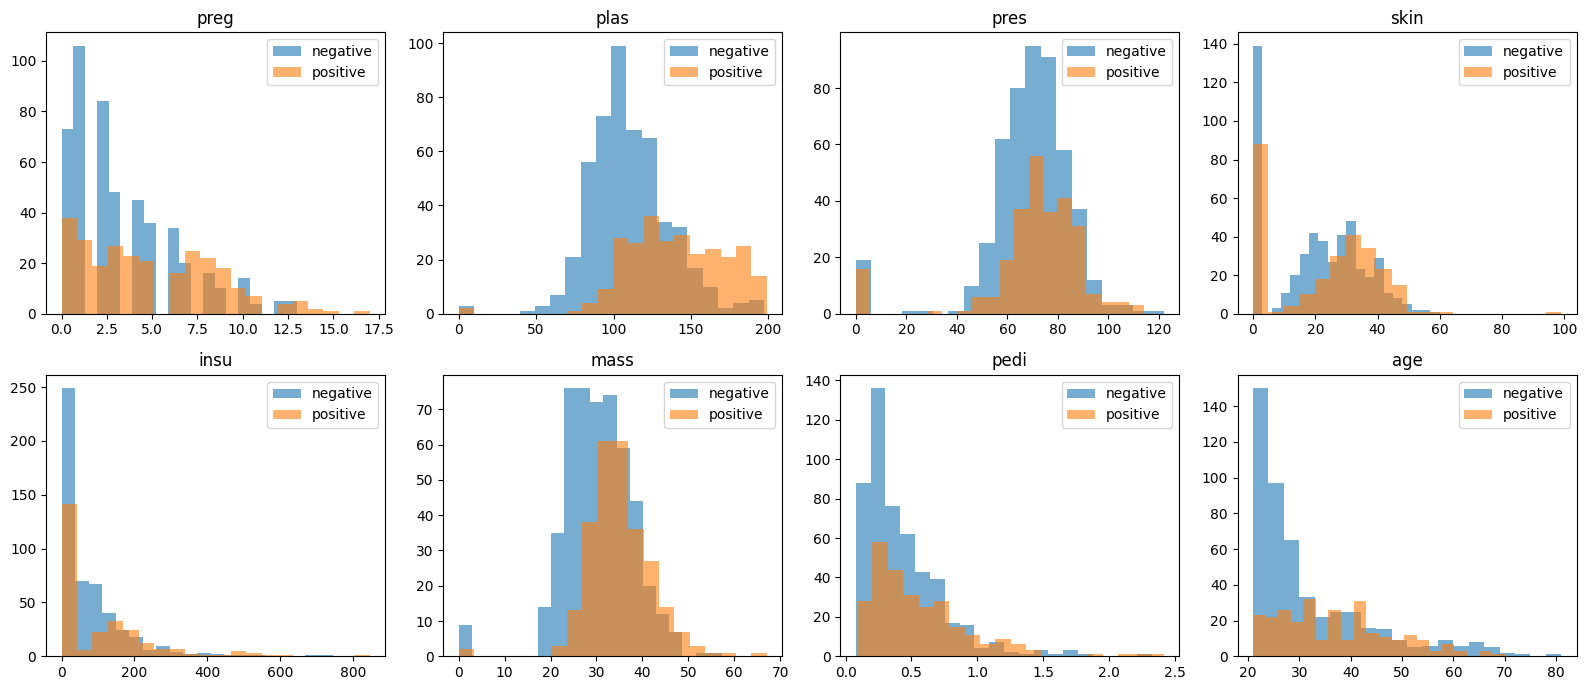

In [42]:
import matplotlib.pyplot as plt

feature_cols = data.columns.drop("class")
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), feature_cols):
    ax.hist(data[data["class"] == "tested_negative"][col],
            bins=20, alpha=0.6, label="negative")
    ax.hist(data[data["class"] == "tested_positive"][col],
            bins=20, alpha=0.6, label="positive")
    ax.set_title(col)
    ax.legend()
fig.tight_layout()
fig.show()

##### Model Development

OK! Let's get to developing some decision tree models to predict diabetes risk. Our first step, as in previous labs, is to split our data into a training set and a test set (unseen data). We will then use k-folds cross validation on the training set to try and get the best performing model before finally applying it to the test data.

The features in this dataset are already numeric, so they don't need any encoding. The only column that needs to be converted is the target `class`, which contains the strings `tested_negative` / `tested_positive`. We use sklearn's [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) to map these to 0 / 1 integers that sklearn can work with.

Let's import sklearn's decision tree classifer, encode the target, and split the data (using techniques we covered in the first lab).

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn import tree # import our decision tree model
from sklearn.preprocessing import LabelEncoder

# Label-encode the target: tested_negative -> 0, tested_positive -> 1
le = LabelEncoder()
data["class"] = le.fit_transform(data["class"])

target_data = data["class"]
feature_data = data.iloc[:, data.columns != "class"]

X_train, X_test, y_train, y_test = train_test_split(feature_data,
                                                    target_data,
                                                    test_size=0.3,
                                                    random_state=0)

* How many samples are in the training set?
* How many samples are in the test set?
* What are the diabetes-positive rates in each of the datasets?

In [ ]:
# YOUR CODE HERE

(537, 8)
(231, 8)
Train positive rate: 0.3612662942271881
Test positive rate: 0.3203463203463203


##### Fitting a Tree

So we've got our data prepared, let's fit a decision tree to our training data.

Remember, the pipeline for model development in sklearn is **initialize->fit->predict**.

In [45]:
from sklearn.metrics import accuracy_score
from sklearn import tree

clf = tree.DecisionTreeClassifier(max_depth = 8)

clf.fit(X_train, y_train)

accuracy = accuracy_score(y_train, clf.predict(X_train))
print ("Accuracy: ", accuracy * 100, "%")


Accuracy:  91.06145251396647 %


In the above cell, we defined a Decision Tree classifier and fit it to our training set.

**YOUR TURN:**
* What is the performance of this model on the test set?
* Do you think the model has overfit or underfit: ____________


In [ ]:
# YOUR CODE HERE: compute and print the test accuracy of `clf`


##### Varying Depth

Now that we know how to fit a tree, lets see what impact the depth of a tree has on its performance. We want to keep the test set untouched until the very end, so instead of evaluating on it we estimate generalization with **k-fold cross-validation on the training set**.

**Your Turn**
* Run the Cell below
* At what depth is the model underfitting and at what depth is the model overfitting? _______________


In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

# Example: how to get a 5-fold CV accuracy estimate for a single model.
# `cross_val_score` returns one score per fold, so we take the mean.
example_clf = tree.DecisionTreeClassifier(max_depth=3)
example_cv = cross_val_score(example_clf, X_train, y_train,
                             cv=5, scoring='accuracy').mean()
print("Example CV accuracy at depth=3:", example_cv)

depths = list(range(2, 8))
train_accs = []
cv_accs = []

for depth in depths:
    # TODO 1: build a DecisionTreeClassifier with max_depth=depth
    # TODO 2: fit it on X_train, y_train and append the *training* accuracy to train_accs
    # TODO 3: use cross_val_score on X_train/y_train (cv=5) and append the *mean* CV accuracy to cv_accs
    pass

# TODO 4: plot train_accs and cv_accs against depths on the same axes.
#         Add a legend, x-label ("max_depth"), y-label ("Accuracy"), and a title.



##### Visualizing the Tree

One useful thing we can do is actually visualize our decision tree model! We can use the [graphViz](https://www.graphviz.org/) library to accomplish this:

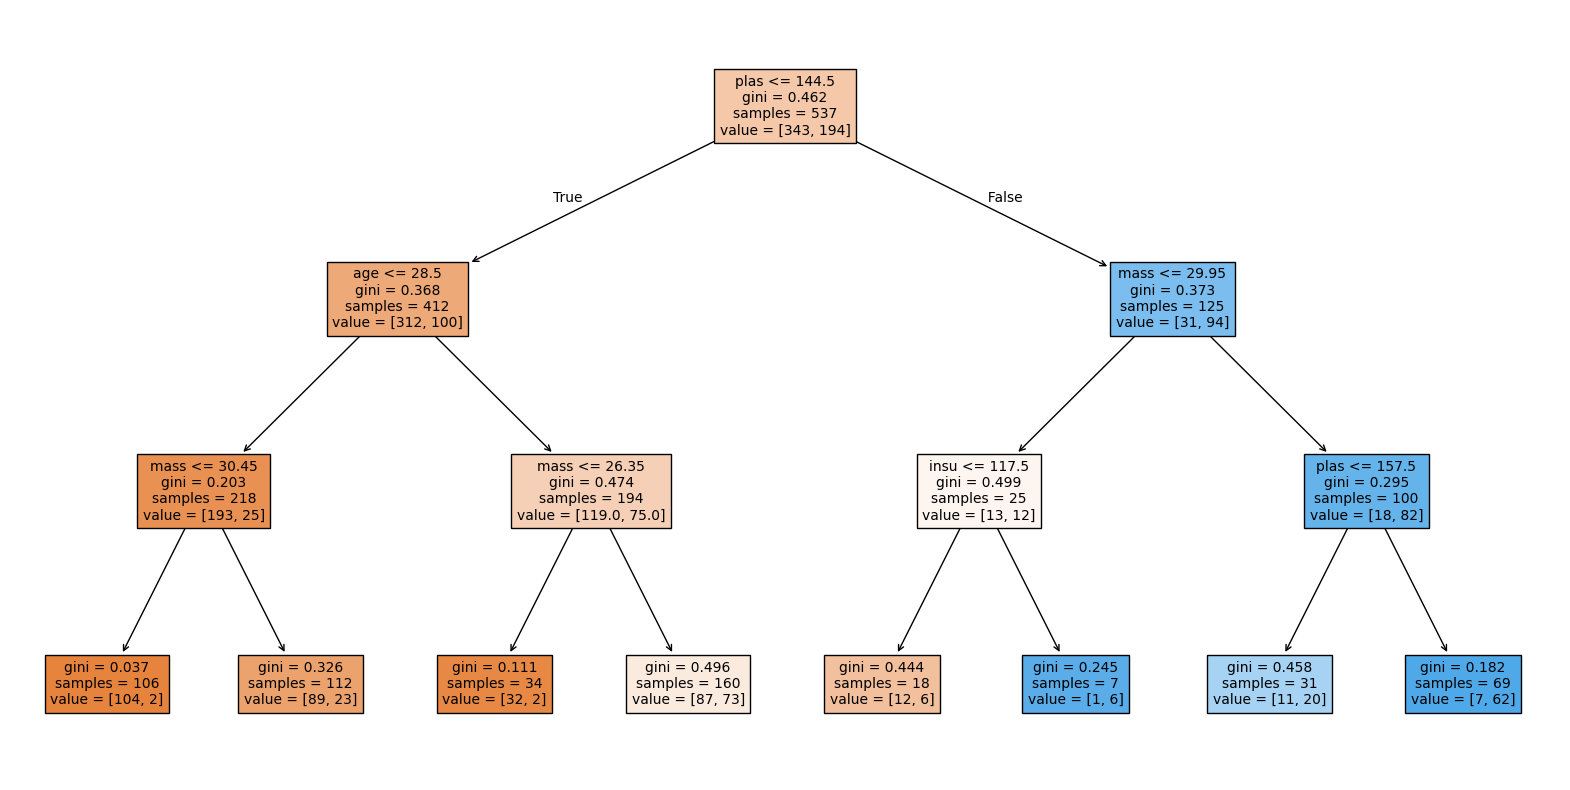

In [50]:
from sklearn.tree import export_graphviz

clf = tree.DecisionTreeClassifier(max_depth = 3)

clf.fit(X_train, y_train)

accuracy = accuracy_score(y_train, clf.predict(X_train))

from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(clf, filled=True, feature_names=data.columns.drop('class'), fontsize=10); # Plot the tree

Lets explore the decision tree and answer the following:
* What feature does the root node split on?
* What features appear most in the tree?

##### HP Tuning
There are many hyper-parameters that can be tuned to change how the model performs. Some common parameters that are modified include:
1. Max Tree Depth: How "tall" do you want your tree to be
2. Minimum Samples Per Leaf: This parameter defines the minimum number of training datapoints that fall into a given leaf node in order for that node to be created

To decide the values of each of the parameters, we can use Grid Search combined with cross validation. In Grid Search, we first decide what potential values we want each hyperparameter will take. Then we find every possible combination of parameters and run cross validation on each combination to estimate the performance of that hyperparameter combination.

Luckily, `sklearn` has a nice implementation of Grid Search that runs this algorithm for us.

Here we want to tune three parameters: max_depth, min_samples_split, and min_samples_leaf. To do this, we need to define possible values we want to search over.


In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

clf = tree.DecisionTreeClassifier() # First we define our model without passing in parameters
hyperparameter_search = { # Then we decide the possible parameter combinations
    'max_depth': [2,3,4,5,6], 
    'min_samples_leaf': [1, 2,4,8],
    'min_impurity_decrease': [0.0, 1e-3],
    'criterion': ['gini','entropy'] 
}
evaluation_metric = make_scorer(accuracy_score, # GridSearchCV requires us to wrap our metric function in a "scorer"
                                greater_is_better = True)

grid_search_cv = GridSearchCV(estimator = clf,
                              param_grid = hyperparameter_search,
                              scoring = evaluation_metric,
                              cv = 5) # Set up search algorithm
grid_search_cv.fit(X_train, y_train) # Run the search. NOTE: This may take a while

print("Best Parameters: ", grid_search_cv.best_params_) # Print the parameters
print ("Best CV Accuracy: ", grid_search_cv.best_score_ * 100, "%")

clf = grid_search_cv.best_estimator_ # Get the best model from the GridSearch
accuracy = accuracy_score(y_test, clf.predict(X_test))
print ("Testing Accuracy: ", accuracy * 100, "%") # Print the testing accuracy of the best model

Best Parameters:  {'criterion': 'entropy', 'max_depth': 6, 'min_impurity_decrease': 0.001, 'min_samples_leaf': 8}
Best CV Accuracy:  74.11561093804085 %
Testing Accuracy:  75.75757575757575 %


In the cell above, we tested our three values per hyperparameter and ran grid search to find the best combination from the space we defined. As you may have noticed, the number of combinations tested by Grid Search exponentially increases as you test more values and tune more hyperparameters. This means that performing a grid search is often a task that takes a long period of time and is often **not** used for more complex models like neural networks.

### Other Models
If you have finished early, feel free to try other models and try to get as high of a test accuracy as you can!

Some other models you can start with:
1. [Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
2. [Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier)
3. [SVM](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)

You can also use models from other packages. Some examples include:
1. [XGBoost](https://xgboost.readthedocs.io/en/stable/get_started.html) (you will need to run `!pip install xgboost`)
2. [LightGBM](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html#lightgbm.LGBMClassifier) (`!pip install lightgbm`)

